# Foraging proof-of-concept: the worm navigates to food (no training)

Building on the turn primitive (`turn_poc.ipynb`), this steers the NCAP swimmer to **seek
food** with `steer_to_food`: a fixed reflex that turns toward the food and swims -- **no
learning**.

What makes it work is the egocentric convention, measured directly against the simulator
(`to_target[0]` = lateral, `+` = food to the worm's LEFT; forward = `-to_target[1]`). The
older steering code had these two axes swapped, which is why earlier foraging attempts
never passed ~47%. With the axes right, this trivial reflex reaches **~90%**. Just run the
cells.

In [1]:
%matplotlib inline
import sys
from pathlib import Path
SRC = str(Path.cwd().parent / 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)

import numpy as np
import matplotlib.pyplot as plt
from macrocircuits import ensure_tonic
ensure_tonic()

import torch, tonic, tonic.torch
from dm_control.mujoco import engine
from macrocircuits.models import ppo_swimmer_model
from macrocircuits.reflex_steering import make_steer_to_food_reflex
from macrocircuits.controllers import make_learned_steering
from macrocircuits.video import write_video
from IPython.display import Video

N_JOINTS = 5
SUCCESS_DIST = 0.15   # head within this of the food at some point => that episode found it
print('ready')

ready


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


## Helpers

Build a fresh (untrained) NCAP swimmer with a controller, roll it out on `foraging`, render it, and score physics-only success.

In [2]:
def _get_physics(env):
    while env is not None:
        if hasattr(env, 'physics'):
            return env.physics
        inner = getattr(env, 'environment', None)
        if inner is not None and hasattr(inner, 'physics'):
            return inner.physics
        env = getattr(env, 'env', None)
    raise RuntimeError('no physics in env chain')


def _arena_frame(physics, distance=5.5):
    """Fixed top-down camera on the whole arena, so you see the worm traverse to food."""
    cam = engine.Camera(physics, height=480, width=640, camera_id=-1)
    rc = cam._render_camera
    rc.lookat[:] = [0.0, 0.0, 0.0]
    rc.distance = distance; rc.azimuth = 90; rc.elevation = -90
    frame = cam.render(); cam._scene.free()
    return frame


def reflex_policy(controller, seed=0):
    """A deterministic policy from a FRESH (untrained) NCAP circuit + the given controller.
    Returns (policy, env, physics); `policy(obs)` -> action, both batched (1, .)."""
    torch.manual_seed(seed)
    model = ppo_swimmer_model(n_joints=N_JOINTS, critic_sizes=(256, 256),
                              action_noise=0.1, controller=controller)
    env = tonic.environments.distribute(
        lambda: tonic.environments.ControlSuite('swimmer-foraging', time_feature=True))
    env.initialize(seed)
    actor = model.actor
    actor.initialize(observation_space=env.observation_space, action_space=env.action_space)
    def policy(obs):
        with torch.no_grad():
            out = actor(torch.as_tensor(obs, dtype=torch.float32))
            return (out.loc if hasattr(out, 'loc') else out).numpy()
    return policy, env, _get_physics(env.environments[0])


def trained_policy(path, seed=0):
    """Load a PPO-trained checkpoint from `path` and return (policy, env, physics)."""
    import argparse, os, yaml
    import macrocircuits.training as _t
    ns = dict(vars(_t))
    cfg = argparse.Namespace(**yaml.load(open(os.path.join(path, 'config.yaml')), Loader=yaml.FullLoader))
    try:
        if cfg.header: exec(cfg.header, ns)
    except Exception:
        pass
    agent = eval(cfg.agent, ns)
    env = tonic.environments.distribute(lambda: eval(cfg.environment, ns))
    env.initialize(seed)
    agent.initialize(observation_space=env.observation_space,
                     action_space=env.action_space, seed=seed)
    cp = os.path.join(path, 'checkpoints')
    ids = [int(n.split('.')[0][5:]) for n in os.listdir(cp) if n.startswith('step_')]
    agent.load(os.path.join(cp, f'step_{max(ids)}'))
    return (lambda obs: agent.test_step(obs, 0)), env, _get_physics(env.environments[0])


def success_rate(policy, env, n_episodes=30):
    """Fraction of fresh episodes whose head comes within SUCCESS_DIST of the food.
    Distance is read from infos['observations'] (the pre-reset transition obs)."""
    tgt = slice(N_JOINTS, N_JOINTS + 2)
    obs = env.start(); mind = np.inf; hits = []
    while len(hits) < n_episodes:
        obs, infos = env.step(policy(obs))
        mind = min(mind, float(np.linalg.norm(infos['observations'][0, tgt])))
        if infos['resets'][0]:
            hits.append(mind < SUCCESS_DIST); mind = np.inf
    return float(np.mean(hits))


def forage_episode(policy, env, physics, steps=1000, viz_food_size=0.10):
    """One episode; records overhead frames, head path, food positions, and the steps
    where a food was reached (it then respawns). viz_food_size only enlarges the food
    marker for the video -- the success metric uses the true tiny food."""
    obs = env.start()
    if viz_food_size:
        physics.named.model.geom_size['target', 0] = viz_food_size; physics.forward()
    frames, hx, hy, fx, fy, eats = [], [], [], [], [], []
    prev_food = None
    for i in range(steps):
        frames.append(_arena_frame(physics))
        nose = physics.named.data.geom_xpos['nose'][:2].copy()
        food = physics.named.data.geom_xpos['target'][:2].copy()
        hx.append(nose[0]); hy.append(nose[1]); fx.append(food[0]); fy.append(food[1])
        if prev_food is not None and np.linalg.norm(food - prev_food) > 1e-6:
            eats.append(i)
        prev_food = food
        obs, infos = env.step(policy(obs))
        if infos['resets'][0]:
            break
    return dict(frames=frames, hx=np.array(hx), hy=np.array(hy),
                fx=np.array(fx), fy=np.array(fy), eats=eats)


def show_video(frames, path, fps=30):
    """Write the frames to an mp4 (imageio) and embed the file directly. This plays
    reliably in VSCode / Jupyter, unlike matplotlib's to_html5_video, which often renders
    blank or hangs in the VSCode notebook viewer."""
    import os
    os.makedirs(os.path.dirname(path), exist_ok=True)
    write_video(path, frames, fps=fps)
    return Video(path, embed=True, width=560)


def plot_path(ep, title):
    plt.figure(figsize=(6.5, 6.5))
    plt.scatter(ep['hx'], ep['hy'], c=np.arange(len(ep['hx'])), cmap='viridis', s=6, label='head path')
    food_pts = np.unique(np.c_[ep['fx'], ep['fy']], axis=0)
    plt.scatter(food_pts[:, 0], food_pts[:, 1], marker='*', s=260, c='red', ec='k', label='food', zorder=5)
    if ep['eats']:
        plt.scatter(ep['hx'][ep['eats']], ep['hy'][ep['eats']], s=90, c='lime', ec='k', label='reached', zorder=6)
    plt.gca().set_aspect('equal'); plt.grid(alpha=0.3); plt.legend()
    plt.title(title); plt.xlabel('world x'); plt.ylabel('world y'); plt.show()

print('helpers ready')

helpers ready


## Watch it forage

One episode with `steer_to_food`: the worm swims out, curves onto the food, and when it reaches one the food respawns elsewhere and it heads for the next.

In [3]:
policy, env, physics = reflex_policy(make_steer_to_food_reflex(N_JOINTS), seed=3)
ep = forage_episode(policy, env, physics, steps=1000)
print(f'food reached this episode: {len(ep["eats"])}')
show_video(ep['frames'][::2], 'output_videos/forage.mp4', fps=30)

C:\Users\lukav\OneDrive\Documents\CogSci\projects\neuroai-macrocircuits\.venv\Lib\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


food reached this episode: 2


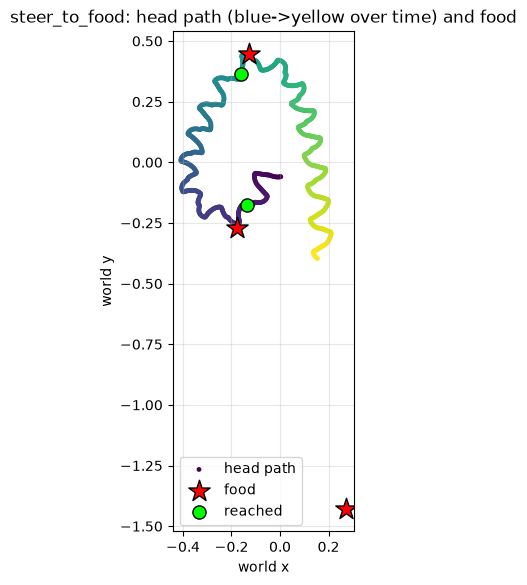

In [4]:
plot_path(ep, 'steer_to_food: head path (blue->yellow over time) and food')

## Success rate

Over 30 fresh episodes, how often the worm actually reaches the food -- against no steering at all (the circuit just swims straight).

no steering     : 23%
steer_to_food   : 90%


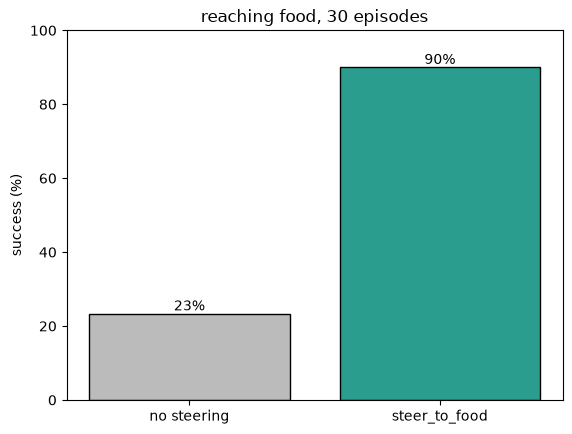

In [5]:
rates = {
    'no steering':   success_rate(*reflex_policy(None)[:2]),
    'steer_to_food': success_rate(*reflex_policy(make_steer_to_food_reflex(N_JOINTS))[:2]),
}
for k, v in rates.items(): print(f'{k:16}: {v*100:.0f}%')
bars = plt.bar(list(rates), [v*100 for v in rates.values()], color=['#bbb', '#2a9d8f'], ec='k')
plt.bar_label(bars, fmt='%.0f%%'); plt.ylabel('success (%)'); plt.ylim(0, 100)
plt.title('reaching food, 30 episodes'); plt.show()

## The learned controller, warm-started (no RL)

`learned_steering` (Option 5) learns the steering decision on top of the same turn primitive. Built here with no checkpoint, it is warm-started (behaviour-cloned) to the correct-sign steerer, so even before any training it already forages at ~90%. The `forage_train_poc.ipynb` notebook trains it with PPO.

In [6]:
print(f'learned_steering (warm-started, no RL): '
      f'{success_rate(*reflex_policy(make_learned_steering(N_JOINTS))[:2])*100:.0f}%')

C:\Users\lukav\OneDrive\Documents\CogSci\projects\neuroai-macrocircuits\.venv\Lib\site-packages\gym\spaces\box.py:127: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


learned_steering (warm-started, no RL): 80%


## Learning curve

The section above shows the learned controller *warm-started only* (no RL). For reference,
here is what PPO training does to it: mean test-episode reward over training, read from an
existing run's `log.csv` (`ls_progress_eat_warm_seed0`). This notebook does **not** train --
see `forage_train_poc.ipynb` to reproduce that run.

In [ ]:
import os
import pandas as pd
from pathlib import Path

# No training here -- visualize an existing PPO run: the warm-started learned_steering
# controller trained on foraging (progress + eat reward). The notebook lives in Ressources/,
# so the data tree is one level up at the repo root.
RUN = Path.cwd().parent / 'data/local/experiments/tonic/swimmer-foraging/ls_progress_eat_warm_seed0'
log = pd.read_csv(RUN / 'log.csv')

col = next(c for c in log.columns if 'episode_score/mean' in c)
# Cumulative env steps -- NOT 'train/epoch_steps' (the constant epoch length, identical at
# every eval point, which collapses the whole curve onto a single x). 'train/steps' ends
# with '/steps' whereas epoch_steps ends with '_steps'.
xcol = next(c for c in log.columns if c.endswith('/steps'))

plt.figure(figsize=(6, 3.5))
plt.plot(log[xcol], log[col], marker='o')
plt.xlabel(xcol); plt.ylabel(col)
plt.title('learned_steering (PPO): training reward'); plt.grid(alpha=0.3); plt.show()